# Step 2 — Specification

> Full prompt for this step, reproduced verbatim (CLAUDE.md code-style rule:
> each notebook opens with its own spec so it is self-contained).

STEP 2 — Exploration: ACF diagnostics + asset clustering

Read CLAUDE.md first. Implement ONLY this step, in notebooks/02_exploration.ipynb.
First cell: this entire prompt in markdown, titled "# Step 2 — Specification".

## Goal
Two diagnostics that justify the system's core design decisions:
(A) show that returns have no exploitable linear structure (white noise)
    while VOLATILITY does — justifying risk estimation over return prediction;
(B) verify that the 7 assets cluster by actual behavior into the groups we
    assume (equity / bonds / gold) — validating real diversification.

## Part A — ACF diagnostics
Use weekly returns (data/returns_weekly.parquet), each asset from its own
inception. For each of the 7 ETFs:
1. ACF of weekly returns, 20 lags, with 95% significance bands
   (statsmodels plot_acf). Expect: nothing significant beyond noise.
2. ACF of SQUARED weekly returns (volatility proxy), 20 lags.
   Expect: strong, slowly-decaying positive autocorrelation
   (volatility clustering).
3. Ljung-Box test (lags=10) on both returns and squared returns per asset.
   Print a summary table: asset | LB p-value returns | LB p-value r².
Present conclusion in a short markdown cell: returns ≈ white noise
(p-values high), volatility persistent (p-values ~0) — hence the system
estimates risk and does not forecast returns.
Keep plots compact: one figure with 7x2 small panels (or two 7-panel figs).

## Part B — Asset clustering
Data: weekly returns, common sample (from VEA inception ~2007-07) so all
assets share the same weeks.
1. Feature per asset = its correlation profile: row of the 7x7 weekly
   correlation matrix (this clusters by co-movement, which is what matters
   for diversification — not by return level).
2. Hierarchical clustering (scipy linkage, method='average',
   distance = 1 - correlation). Plot the dendrogram with asset labels.
3. K-means on the same features for k=2 and k=3; print cluster membership
   per k. (Standardize features first.)
4. Short markdown conclusion: do the data-driven groups match our design
   assumption? Expected: {SPY, VEA, XLE, XLU} equity block, {IEF, SHY}
   rates block, {GLD} alone. Flag anything that deviates.

## Sanity notes
- Do NOT use daily returns anywhere in this step (CLAUDE.md rule 3).
- No modeling beyond diagnostics; no portfolio math yet.
- If XLU shows weaker equity-block membership than the others, that is
  expected (defensive sector) — note it, don't "fix" it.


## 0 — Setup

Load the **weekly** returns produced in Step 1. Per CLAUDE.md rule 3 and this
step's sanity notes, we use weekly returns *only* — no daily data anywhere.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pathlib import Path

ETFS = ["SPY", "VEA", "XLE", "XLU", "IEF", "SHY", "GLD"]

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = ROOT / "data"

rw = pd.read_parquet(DATA_DIR / "returns_weekly.parquet")[ETFS]
print("weekly returns:", rw.shape, "|", rw.index.min().date(), "->", rw.index.max().date())
print("per-asset usable weeks (own inception):")
for c in ETFS:
    print(f"  {c:4s} {rw[c].first_valid_index().date()}  n={rw[c].dropna().shape[0]}")

weekly returns: (1388, 7) | 2000-01-07 -> 2026-08-07
per-asset usable weeks (own inception):
  SPY  2000-01-14  n=1387
  VEA  2007-08-03  n=993
  XLE  2000-01-14  n=1387
  XLU  2000-01-14  n=1387
  IEF  2002-08-09  n=1253
  SHY  2002-08-09  n=1253
  GLD  2004-11-26  n=1133


# Part A — ACF diagnostics

**Question:** is there exploitable *linear* structure in returns? And does
*volatility* persist?

If weekly returns are ~white noise (no significant autocorrelation) but
**squared** returns show strong, slowly-decaying autocorrelation (volatility
clustering), then the honest thing to model is **risk**, not the direction of
returns. That is exactly the premise of this project (CLAUDE.md rule 4: never
estimate expected returns as an optimizer input).

Each asset uses its **own inception** history (not the common sample).

### A.1–A.2 — ACF of returns (left) vs squared returns (right)

7×2 grid: left column = ACF of weekly returns, right column = ACF of squared
weekly returns. Both with 20 lags and 95% significance bands (shaded). Look
for: left ≈ inside the bands (noise); right ≈ many positive lags outside the
bands, decaying slowly (clustering).

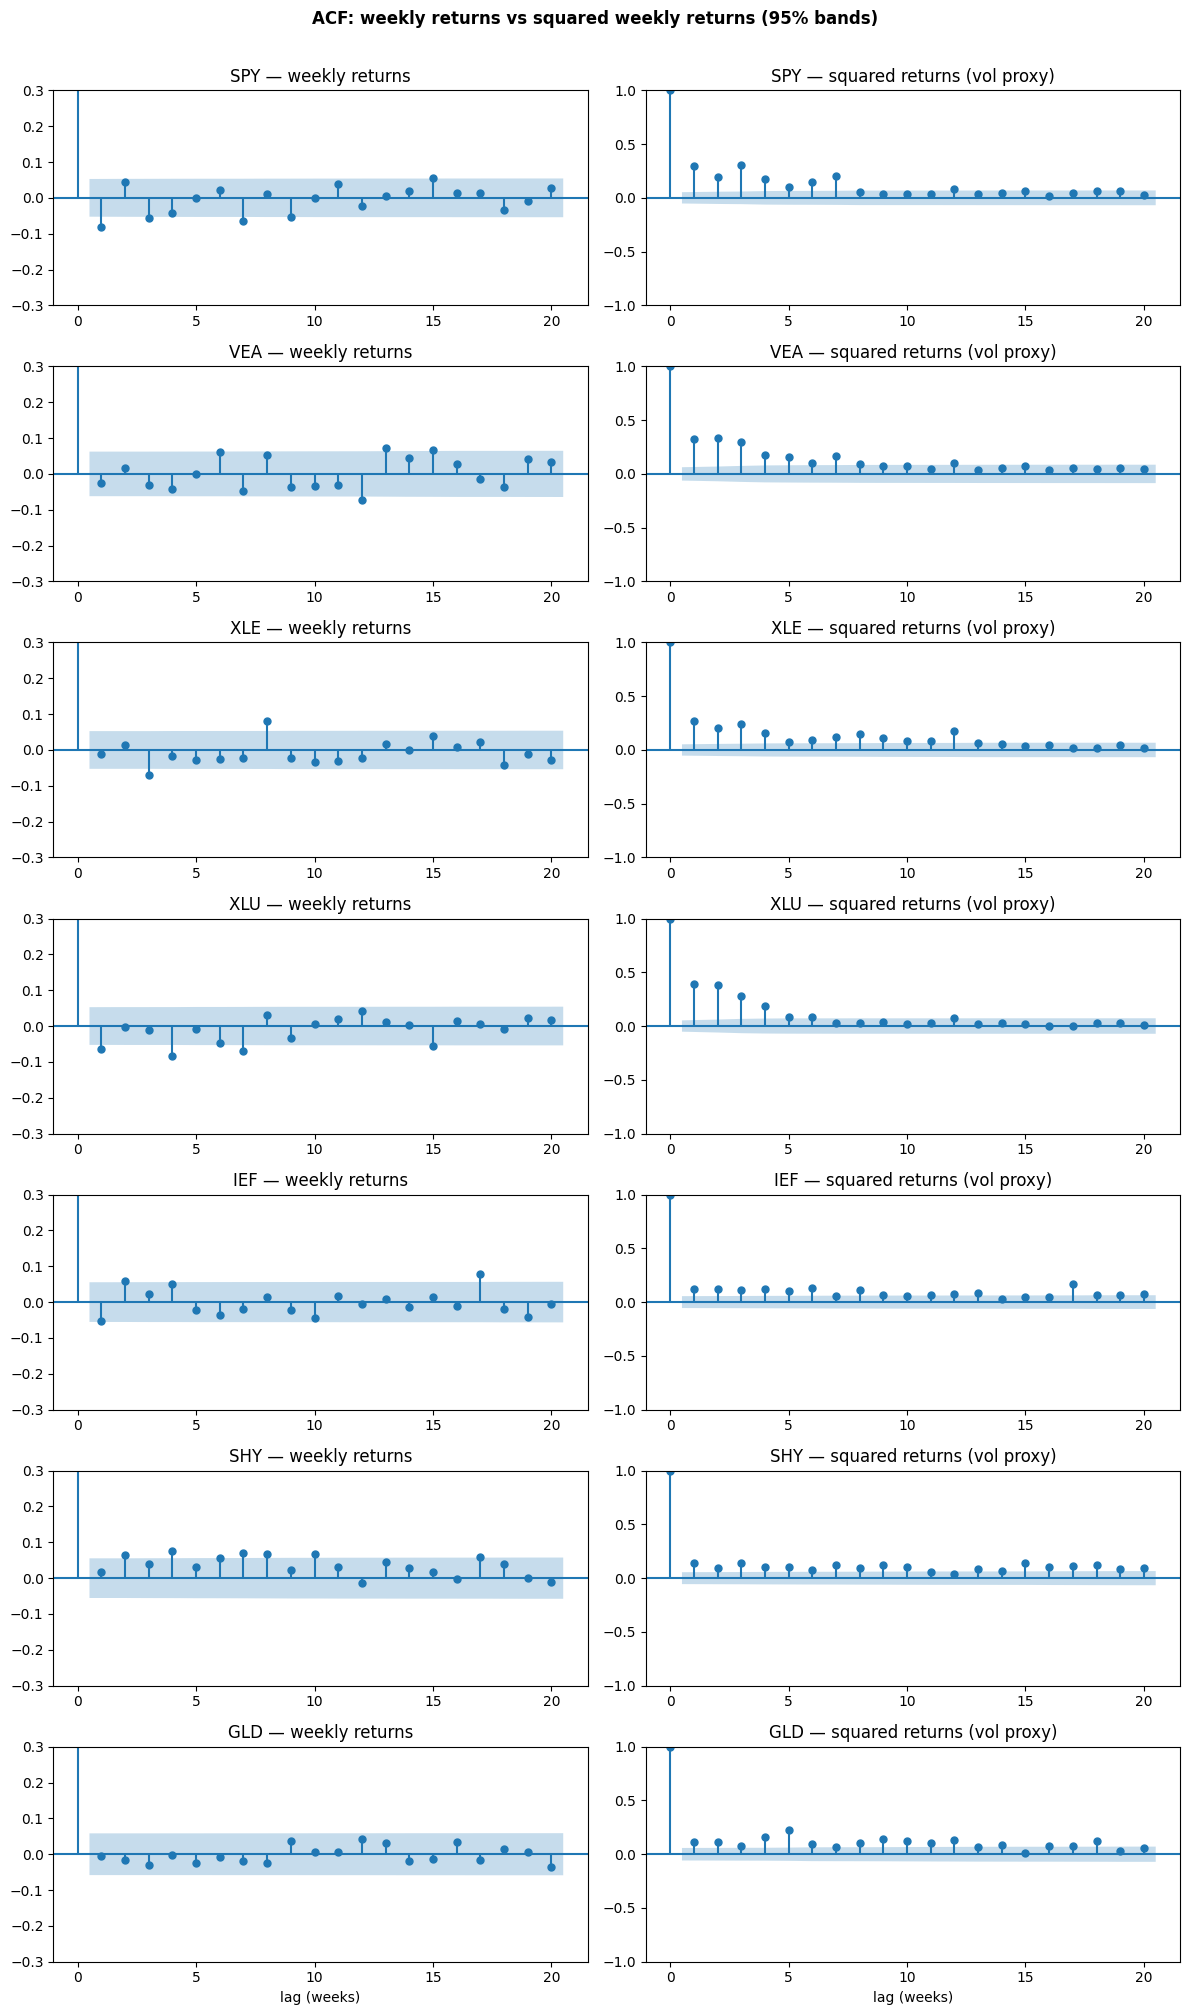

In [2]:
fig, axes = plt.subplots(len(ETFS), 2, figsize=(12, 20))
for i, a in enumerate(ETFS):
    r = rw[a].dropna()
    plot_acf(r, lags=20, alpha=0.05, ax=axes[i, 0],
             title=f"{a} — weekly returns")
    plot_acf(r ** 2, lags=20, alpha=0.05, ax=axes[i, 1],
             title=f"{a} — squared returns (vol proxy)")
    axes[i, 0].set_ylim(-0.3, 0.3)   # returns: zoom to see they hug zero
for ax in axes[-1, :]:
    ax.set_xlabel("lag (weeks)")
fig.suptitle("ACF: weekly returns vs squared weekly returns (95% bands)",
             fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

### A.3 — Ljung-Box test (10 lags) + effect sizes

Formalizes the eyeball test. Null hypothesis = no autocorrelation up to lag 10.
We report the LB p-value **and** `max|acf|` (the largest absolute autocorrelation
over lags 1–10), because with ~1000–1400 weekly observations even an economically
trivial autocorrelation can be *statistically* significant. For a trading system
what matters is the **effect size**, not the p-value alone.

- **Returns:** expect **tiny** `max|acf|` (a few %). Some p-values may still
  reject in a large sample — that structure is too small to exploit after costs.
- **Squared returns:** expect **large** `max|acf|` and p-values ~0 — real,
  persistent volatility.

In [3]:
from statsmodels.tsa.stattools import acf

rows = []
for a in ETFS:
    r = rw[a].dropna()
    p_ret = acorr_ljungbox(r, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    p_sq = acorr_ljungbox(r ** 2, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    # effect size = largest |autocorrelation| over lags 1..10
    mx_ret = np.abs(acf(r, nlags=10, fft=True)[1:]).max()
    mx_sq = np.abs(acf(r ** 2, nlags=10, fft=True)[1:]).max()
    rows.append({
        "LB_p_returns": p_ret, "max|acf|_ret": mx_ret,
        "LB_p_sq_ret": p_sq, "max|acf|_sq": mx_sq,
    })
lb = pd.DataFrame(rows, index=ETFS)

show = lb.copy()
show["LB_p_returns"] = show["LB_p_returns"].map(lambda x: f"{x:.2g}")
show["LB_p_sq_ret"] = show["LB_p_sq_ret"].map(lambda x: f"{x:.2g}")
show["max|acf|_ret"] = show["max|acf|_ret"].map(lambda x: f"{x:.3f}")
show["max|acf|_sq"] = show["max|acf|_sq"].map(lambda x: f"{x:.3f}")
show = show[["LB_p_returns", "max|acf|_ret", "LB_p_sq_ret", "max|acf|_sq"]]
print(show.to_string())
print(f"\nAverage max|acf|:  returns = {lb['max|acf|_ret'].mean():.3f}"
      f"   squared = {lb['max|acf|_sq'].mean():.3f}")

    LB_p_returns max|acf|_ret LB_p_sq_ret max|acf|_sq
SPY       0.0011        0.081     1.3e-91       0.305
VEA         0.13        0.063     4.7e-83       0.331
XLE        0.014        0.081       1e-73       0.268
XLU       0.0018        0.082    3.4e-122       0.396
IEF        0.057        0.060     2.6e-24       0.128
SHY      3.1e-05        0.076     1.6e-29       0.145
GLD         0.91        0.036       1e-36       0.227

Average max|acf|:  returns = 0.069   squared = 0.257


### Part A — conclusion

Two things stand out in the table:

- **Returns carry no *exploitable* linear structure.** The largest weekly
  autocorrelation is only a few percent for every asset. A few LB p-values *do*
  reject "no autocorrelation" (e.g. SPY, XLE, XLU, SHY) — but that is simply the
  large sample (~1000–1400 weeks) detecting economically trivial effects: an
  autocorrelation of ~0.05 is worthless once transaction costs are paid. This is
  the difference between *statistical* and *economic* significance.
- **Volatility is overwhelmingly persistent.** For squared returns `max|acf|` is
  several times larger and the LB p-values are astronomically small (~1e-24 to
  1e-122). The ACF decays slowly — textbook volatility clustering.

The gap between the two — trivial, borderline-significant structure in returns
vs massive, unambiguous structure in volatility — is the whole point.

**Design implication:** the system estimates and manages **risk** (covariance,
regimes, exposure) and does **not** forecast return direction. Momentum enters
only later as a *capped tilt after* optimization, never as an expected-return
input (CLAUDE.md rules 4 & 6).

# Part B — Asset clustering

**Question:** do the 7 assets actually group by behavior into the equity /
rates / gold blocks we assume? If they do, the diversification is real; if not,
we would be fooling ourselves about it.

We cluster on **co-movement** (correlation), not on return level — two assets
with different average returns but that move together give little
diversification.

Data = weekly returns on the **common sample** (all 7 present), so every
correlation is measured over identical weeks.

In [4]:
common = rw.dropna()   # all 7 assets present -> from VEA inception
corr = common.corr()
print(f"Common sample: {common.index.min().date()} -> {common.index.max().date()} (n={len(common)})")
print("\n7x7 weekly correlation (clustering features = each asset's row):")
print(corr.round(2).to_string())

Common sample: 2007-08-03 -> 2026-08-07 (n=993)

7x7 weekly correlation (clustering features = each asset's row):
Ticker   SPY   VEA   XLE   XLU   IEF   SHY   GLD
Ticker                                          
SPY     1.00  0.88  0.67  0.61 -0.21 -0.19  0.07
VEA     0.88  1.00  0.68  0.57 -0.17 -0.14  0.19
XLE     0.67  0.68  1.00  0.47 -0.29 -0.23  0.14
XLU     0.61  0.57  0.47  1.00  0.09  0.01  0.19
IEF    -0.21 -0.17 -0.29  0.09  1.00  0.76  0.23
SHY    -0.19 -0.14 -0.23  0.01  0.76  1.00  0.25
GLD     0.07  0.19  0.14  0.19  0.23  0.25  1.00


### B.2 — Hierarchical clustering (average linkage, distance = 1 − corr)

Distance between two assets = `1 − correlation` (0 = move identically, larger =
less related). Average-linkage dendrogram; the height at which two branches join
is how dissimilar they are.

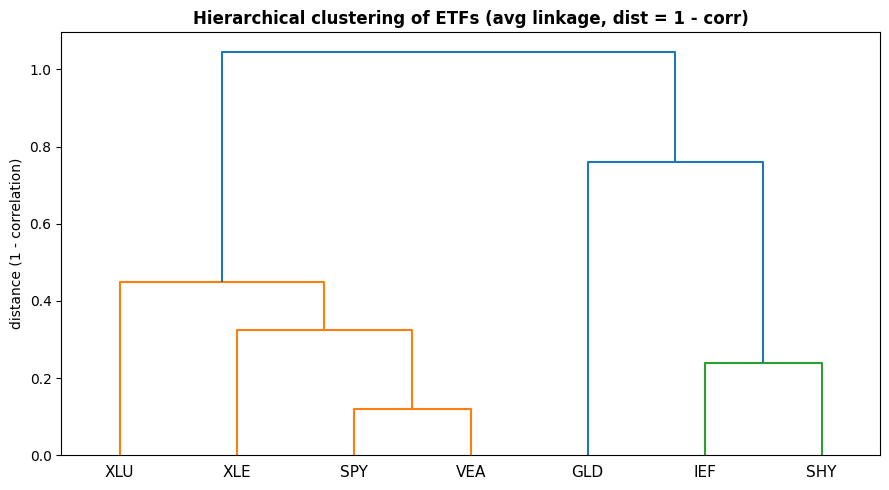

In [5]:
D = 1.0 - corr.values
np.fill_diagonal(D, 0.0)            # exact zero diagonal (float safety)
condensed = squareform(D, checks=False)
Z = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(Z, labels=ETFS, ax=ax, leaf_font_size=11, color_threshold=0.7)
ax.set_title("Hierarchical clustering of ETFs (avg linkage, dist = 1 - corr)",
             fontweight="bold")
ax.set_ylabel("distance (1 - correlation)")
plt.tight_layout()
plt.show()

### B.3 — K-means on the correlation profiles (k = 2 and k = 3)

Features = each asset's correlation-profile row, **standardized** per feature.
K-means is deterministic here (`random_state=0`).

In [6]:
X = StandardScaler().fit_transform(corr.values)   # features = correlation rows

for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    print(f"k={k}:")
    groups = {}
    for asset, lab in zip(ETFS, km.labels_):
        groups.setdefault(int(lab), []).append(asset)
    for lab in sorted(groups):
        print(f"   cluster {lab}: {groups[lab]}")
    print()

k=2:
   cluster 0: ['SPY', 'VEA', 'XLE', 'XLU']
   cluster 1: ['IEF', 'SHY', 'GLD']

k=3:
   cluster 0: ['SPY', 'VEA', 'XLE', 'XLU']
   cluster 1: ['IEF', 'SHY']
   cluster 2: ['GLD']



### Part B — conclusion

**Design assumption:** `{SPY, VEA, XLE, XLU}` equity block, `{IEF, SHY}` rates
block, `{GLD}` on its own.

Compare against the dendrogram and the k=3 K-means membership above:

- The **rates block `{IEF, SHY}`** should join tightly and low (both Treasuries,
  correlation ~0.8) — clearly separate from equities.
- The **equity block `{SPY, VEA, XLE, XLU}`** should group together, negatively
  or near-zero correlated with the rates block.
- **`GLD`** should sit apart from both (low correlation with everything).
- **XLU** may attach to the equity block more loosely than SPY/VEA/XLE — that is
  *expected* for a defensive utilities sector, not a bug (per the sanity notes).

If the k=3 partition reproduces {equity} / {rates} / {gold}, the data confirm the
three behavioral blocks and the diversification premise holds. Any real deviation
(e.g. GLD merging into a block, or the rates block splitting) is flagged here for
attention rather than "fixed".

## Sanity notes (checklist for this step)

- **Weekly returns only** — no daily data used anywhere (CLAUDE.md rule 3).
- **Diagnostics only** — no covariance, weights, or portfolio math (that starts
  at Step 3).
- **XLU** looser equity membership is expected (defensive sector) and noted, not
  corrected.

Step 2 produces no data files — it is exploratory. Findings justify Steps 3–7
(estimate risk, not returns) and confirm the three behavioral blocks.